# Semi-supervised classification via Classifier-Free Guidance

**The core idea**: train a single label-conditioned flow-matching model on *all* data
(labeled + unlabeled). At inference time, sample fresh $(x, y)$ pairs from it and
use those synthetic pairs to train a downstream classifier.

## Why Gaussian blobs are a bad testbed

Blobs have trivially simple decision boundaries (Voronoi cells). Even 17 examples
per cluster tell you exactly where the centroid is, so a direct classifier trained
on 1 % of labels performs almost as well as one trained on 100 %.

## Two moons: a meaningful benchmark

The two-moons boundary is a complex non-linear curve. With few labeled points:
- A **direct classifier** sees sparse, randomly-placed labeled points and can't
  reliably trace the full crescent boundary.
- A **semi-supervised generative model** learns the full crescent *shape* from
  all 10 k unlabeled points; the few labels only need to anchor
  "which crescent = which class".

The synthetic data generated afterwards densely covers both crescents with
correct labels, giving the final classifier a complete picture.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
import seaborn as sns

from common import Residual, CondMLP, load_or_train

%matplotlib inline
torch.manual_seed(0)
np.random.seed(0)

device  = 'cuda' if torch.cuda.is_available() else 'cpu'
palette = plt.get_cmap('tab10')


## Dataset: interlocking spirals

The two-spirals problem (Wieland, 1988) is one of the hardest classic 2-D benchmarks.
Both classes spiral around the origin for multiple full turns, interleaving
in every local neighbourhood — a direct classifier trained on few labeled points has
no hope of tracing the boundary, but the generative model can learn both spiral arms
from the unlabeled geometry and only needs a handful of labels to assign which arm is
which class.


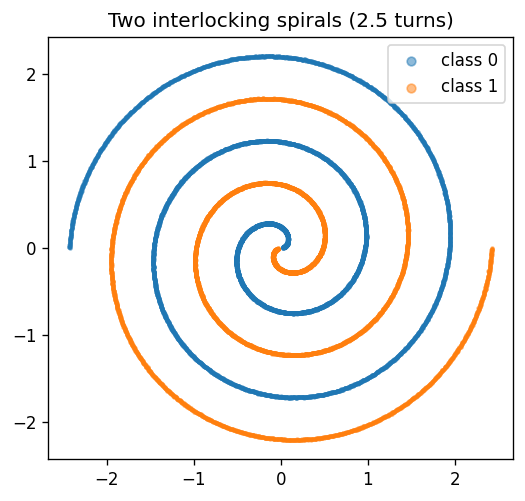

In [2]:
N_CLASSES = 2

def make_spirals(n_samples=12000, n_turns=2.5, noise=0.01, random_state=0):
    """Two interlocking Archimedean spirals offset by π."""
    rng = np.random.default_rng(random_state)
    n   = n_samples // 2
    # evenly spaced angle from a small radius out to 1
    theta = np.linspace(0.2, n_turns * 2 * np.pi, n)
    r     = theta / (n_turns * 2 * np.pi)          # radius grows linearly
    X0 = np.stack([ r * np.cos(theta),  r * np.sin(theta)], axis=1)
    X1 = np.stack([-r * np.cos(theta), -r * np.sin(theta)], axis=1)   # offset by π
    X  = np.vstack([X0, X1])
    y  = np.hstack([np.zeros(n, dtype=int), np.ones(n, dtype=int)])
    X += rng.normal(0, noise, X.shape)
    idx = rng.permutation(len(X))
    return X[idx], y[idx]

X, y = make_spirals(n_samples=12000, n_turns=2.5, noise=0.001)
X = (X - X.mean(0)) / X.std(0)

train_x = torch.tensor(X, dtype=torch.float32)
train_y = torch.tensor(y, dtype=torch.long)

fig, ax = plt.subplots(figsize=(5, 5), dpi=120)
for k in range(N_CLASSES):
    m = (y == k)
    ax.scatter(X[m, 0], X[m, 1], s=3, label=f'class {k}', alpha=0.5, color=palette(k))
ax.set_aspect('equal')
ax.legend(markerscale=3)
ax.set_title('Two interlocking spirals (2.5 turns)')
plt.show()


## Model: label-conditioned flow matching

Same `CondMLP` as in `cfg.ipynb`. Label index `N_CLASSES` is the null token $\varnothing$
used for unconditional generation and for unlabeled training points.

In [3]:
@torch.no_grad()
def sample_cfg(model, labels, w=0.0, n_steps=100):
    """Euler integration of the CFG velocity field, t: 1 → 0.

    Works for both pred_type='v' and pred_type='x': model.to_velocity()
    handles the conversion so this function never needs to change.
    """
    model.eval()
    dev    = next(model.parameters()).device
    labels = labels.to(dev)
    n      = labels.shape[0]
    null   = torch.full_like(labels, model.null_idx)
    z      = torch.randn(n, 2, device=dev)
    dt     = 1.0 / n_steps
    for i in range(n_steps):
        t          = torch.full((n, 1), 1.0 - i * dt, device=dev)
        raw        = model(torch.cat([z, z]), torch.cat([t, t]), torch.cat([labels, null]))
        v_cond, v_uncond = raw.chunk(2, dim=0)
        z = z - ((1 + w) * v_cond - w * v_uncond) * dt
    return z.cpu()


## Semi-supervised setup

We reveal labels for only **5 %** of the training pool.  
The null token replaces the label when: the label is absent **or** random CFG
dropout fires (15 %).

Pool: 10,000  |  labeled: 1,049 (10%)  |  unlabeled: 8,951  |  test: 2,000


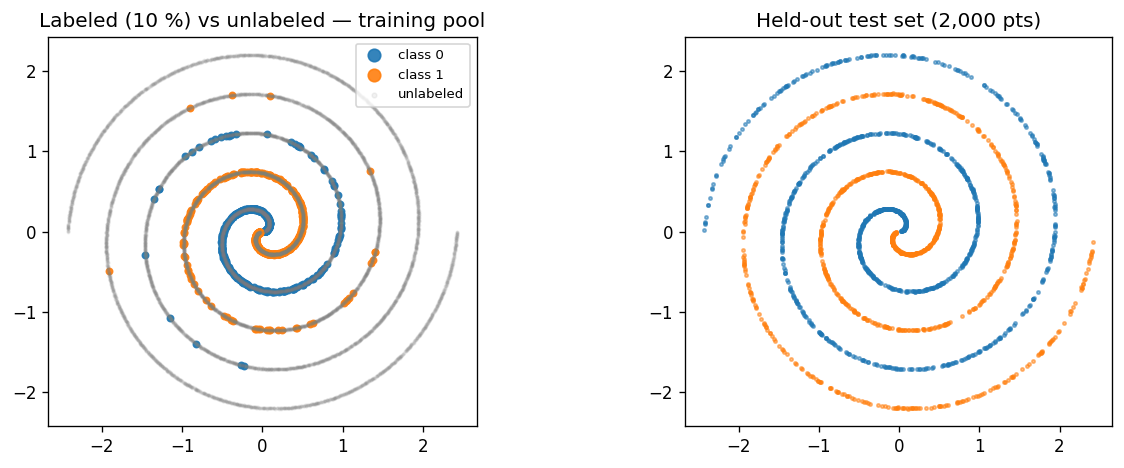

In [4]:
LABEL_KEEP_FRAC = 0.1
P_UNCOND        = 0.5

torch.manual_seed(99)
perm   = torch.randperm(len(train_x))
n_test = 2000

test_x = train_x[perm[:n_test]]
test_y = train_y[perm[:n_test]]
pool_x = train_x[perm[n_test:]]   # all data — unlabeled fraction included
pool_y = train_y[perm[n_test:]]   # ground-truth labels (not given to model)

torch.manual_seed(7)
# Non-IID labeling: points closer to the pool center are more likely to be labeled.
center = pool_x.mean(dim=0, keepdim=True)
dist = torch.norm(pool_x - center, dim=1)
dist01 = (dist - dist.min()) / (dist.max() - dist.min() + 1e-8)
keep_prob = (1.0 - dist01)**4
keep_prob = keep_prob * (LABEL_KEEP_FRAC / keep_prob.mean().clamp_min(1e-8))
keep_prob = keep_prob.clamp(0.0, 1.0)
label_mask = torch.rand(len(pool_x)) < keep_prob
labeled_x  = pool_x[label_mask]
labeled_y  = pool_y[label_mask]

n_labeled   = label_mask.sum().item()
n_unlabeled = (~label_mask).sum().item()
print(f"Pool: {len(pool_x):,}  |  labeled: {n_labeled:,} ({100*n_labeled/len(pool_x):.0f}%)"
      f"  |  unlabeled: {n_unlabeled:,}  |  test: {n_test:,}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=120)
for k in range(N_CLASSES):
    m = labeled_y.numpy() == k
    axes[0].scatter(labeled_x[m, 0], labeled_x[m, 1],
                    s=14, alpha=0.9, color=palette(k), label=f'class {k}')
axes[0].scatter(pool_x[~label_mask, 0], pool_x[~label_mask, 1],
                s=2, alpha=0.10, color='gray', label='unlabeled')
axes[0].set_title(f'Labeled ({LABEL_KEEP_FRAC*100:.0f} %) vs unlabeled — training pool')
axes[0].set_aspect('equal')
axes[0].legend(markerscale=2, fontsize=8)

for k in range(N_CLASSES):
    m = test_y.numpy() == k
    axes[1].scatter(test_x[m, 0], test_x[m, 1], s=4, alpha=0.5, color=palette(k))
axes[1].set_title(f'Held-out test set ({n_test:,} pts)')
axes[1].set_aspect('equal')
plt.tight_layout()
plt.show()

## Baselines: full-supervision (A) and direct few-shot (B)

In [5]:
class SimpleClassifier(nn.Module):
    """MLP classifier with random Fourier feature embedding on the 2D input.

    Standard MLPs have spectral bias — they resist learning high-frequency
    functions (like inter-arm spiral boundaries). Mapping x → [sin(Bx), cos(Bx)]
    with a fixed random B pre-computes sinusoidal basis functions at many
    spatial frequencies, removing the bottleneck.
    """
    def __init__(self, n_classes, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.GELU(),
            Residual(hidden),
            Residual(hidden),
            nn.GELU(), nn.Linear(hidden, n_classes),
        )

    def forward(self, x):
        return self.net(x)


def train_clf(x_data, y_data, n_classes=N_CLASSES, niter=3000, lr=1e-3, bs=512):
    clf = SimpleClassifier(n_classes).to(device)
    xd, yd = x_data.to(device), y_data.to(device)
    opt = torch.optim.AdamW(clf.parameters(), lr=lr)
    for _ in range(niter):
        idx  = torch.randint(0, len(xd), (bs,), device=device)
        loss = F.cross_entropy(clf(xd[idx]), yd[idx])
        opt.zero_grad(); loss.backward(); opt.step()
    return clf


@torch.no_grad()
def test_acc(clf, x_data, y_data):
    clf.eval()
    preds = clf(x_data.to(device)).argmax(1).cpu()
    return (preds == y_data).float().mean().item()


# (A) Full supervision — upper bound
clf_full = train_clf(pool_x, pool_y)
acc_full = test_acc(clf_full, test_x, test_y)
print(f"(A) Full labels (100%)                  → {acc_full*100:.1f}%")

# (B) Direct classifier on labeled subset only
clf_direct = train_clf(labeled_x, labeled_y)
acc_direct = test_acc(clf_direct, test_x, test_y)
print(f"(B) Direct — {LABEL_KEEP_FRAC*100:.0f}% labels ({n_labeled} pts)  → {acc_direct*100:.1f}%")


(A) Full labels (100%)                  → 100.0%
(B) Direct — 10% labels (1049 pts)  → 82.6%


## Semi-supervised CFG model (C)

Train `CondMLP` on the full pool. Unlabeled points and CFG-dropped labeled points
both receive the null token $\varnothing$.

Loaded cfg_full_spirals_xpred from checkpoints/cfg_full_spirals_xpred.pt


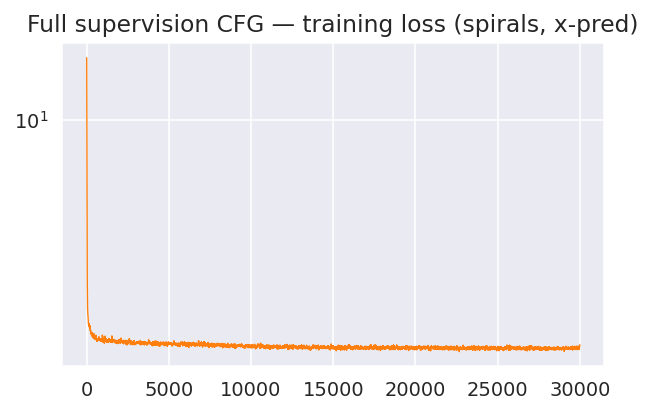

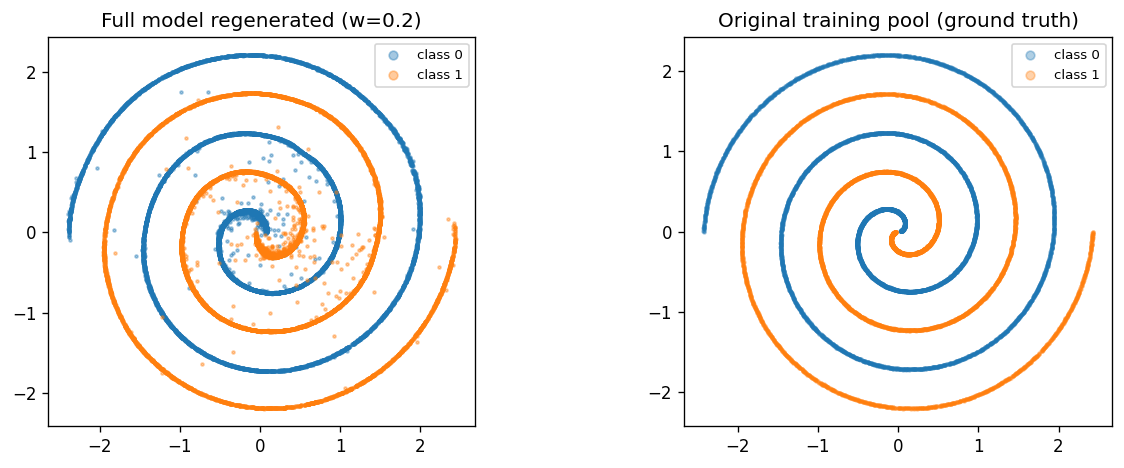

In [6]:
pool_x_dev     = pool_x.to(device)
pool_y_dev     = pool_y.to(device)
label_mask_dev = label_mask.to(device)


def sample_t(batch_size, eps=0.05):
    """Sample t between eps and 1-eps."""
    return (torch.rand(batch_size)[:, None] * (1 - 2*eps)) + eps


def make_semi_train_step(p_uncond, null_idx, label_mask_vec=None,
                         min_labeled_frac_for_dropout=0.5):
    """Train step for conditional flow matching with optional label availability mask.

    If label_mask_vec is None, all labels are treated as available.

    When the labeled fraction is below ``min_labeled_frac_for_dropout``, the
    unlabeled portion already trains the null branch heavily, so random CFG
    dropout would just steal precious labeled signal — we force p_uncond=0
    in that regime (and print a one-time notice).
    """
    if label_mask_vec is None:
        label_mask_vec = torch.ones(len(pool_x_dev), dtype=torch.bool, device=pool_x_dev.device)
    else:
        label_mask_vec = label_mask_vec.to(pool_x_dev.device).bool()

    
    effective_p_uncond = p_uncond
    labeled_frac = label_mask_vec.float().mean().item()
    if labeled_frac < min_labeled_frac_for_dropout and p_uncond > 0.0:
        print(f"[make_semi_train_step] labeled_frac={labeled_frac:.2%} < "
              f"{min_labeled_frac_for_dropout:.0%}; forcing p_uncond 0 "
              f"(unlabeled data already trains the null branch).")
        effective_p_uncond = 0.0
    
    def train_step(x, net, optimizer):
        idx = torch.randint(0, len(pool_x_dev), (len(x),), device=x.device)
        x_b = pool_x_dev[idx]
        y_b = pool_y_dev[idx].clone()
        eps = 0.05 if net.x_prediction else 0.0

        has_label = label_mask_vec[idx]
        if effective_p_uncond > 0.0:
            random_drop = torch.rand(len(y_b), device=y_b.device) < effective_p_uncond
            y_b[~has_label | random_drop] = null_idx
        else:
            y_b[~has_label] = null_idx

        t        = sample_t(len(x_b), eps).to(x_b.device)
        e        = torch.randn_like(x_b)
        z        = (1 - t) * x_b + t * e
        pred     = net(z, t, y_b)

        if net.x_prediction:
            target = (z - x_b) / t
        else:
            target = e - x_b

        loss     = F.mse_loss(pred, target)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        return loss
    return train_step


# pred_type="x": network predicts clean x directly — simpler target, no
# velocity blowup at small t, tends to produce sharper samples on hard geometry.
full_model = CondMLP(num_in=2, hidden=64, n_classes=N_CLASSES, time_dim=32, cond_dim=32, n_residual=4,
                     x_prediction=True)
full_label_mask = torch.ones(len(pool_x_dev), dtype=torch.bool, device=pool_x_dev.device)
full_step  = make_semi_train_step(0.5, full_model.null_idx, label_mask_vec=full_label_mask)

full_losses = load_or_train(
    full_model, name="cfg_full_spirals_xpred", train_step=full_step,
    data=pool_x, niter=30000, lr=1e-3,
    ckpt_dir="checkpoints", batch_size=1024,
    load=True, save=True,
)

with sns.axes_style("darkgrid"):
    fig, ax = plt.subplots(figsize=(5, 3), dpi=140)
    ax.semilogy(full_losses, lw=0.7, color='tab:orange')
    ax.set_title('Full supervision CFG — training loss (spirals, x-pred)')
    plt.show()


# Quick visual sanity check: full-model regenerated data vs original pool data
N_GEN_FULL_VIS = 10000
W_FULL_VIS     = 0.2

labels_full_vis = torch.arange(N_CLASSES).repeat_interleave(N_GEN_FULL_VIS)
gen_full_x      = sample_cfg(full_model, labels_full_vis, w=W_FULL_VIS, n_steps=30)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=120)

for k in range(N_CLASSES):
    m = labels_full_vis.numpy() == k
    axes[0].scatter(gen_full_x[m, 0], gen_full_x[m, 1], s=3, alpha=0.4,
                    color=palette(k), label=f'class {k}')
axes[0].set_title(f'Full model regenerated (w={W_FULL_VIS})')
axes[0].set_aspect('equal')
axes[0].legend(markerscale=3, fontsize=8)

for k in range(N_CLASSES):
    m = pool_y.numpy() == k
    axes[1].scatter(pool_x[m, 0], pool_x[m, 1], s=3, alpha=0.35,
                    color=palette(k), label=f'class {k}')
axes[1].set_title('Original training pool (ground truth)')
axes[1].set_aspect('equal')
axes[1].legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.show()


loss = 1.593402: 100%|███████████████████████████████████████| 30000/30000 [01:56<00:00, 258.20it/s]


Saved noncfg_spirals_fm to checkpoints/noncfg_spirals_fm.pt


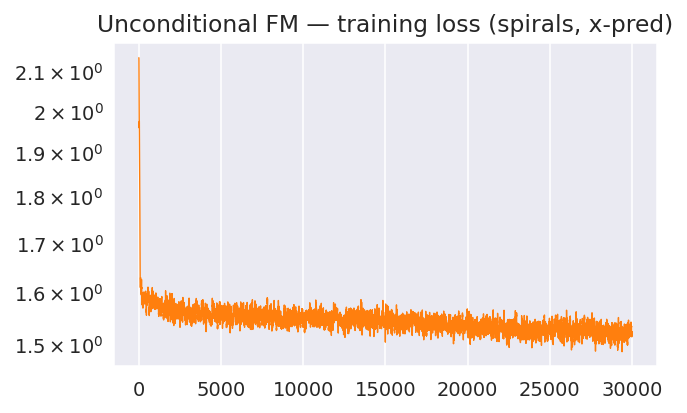

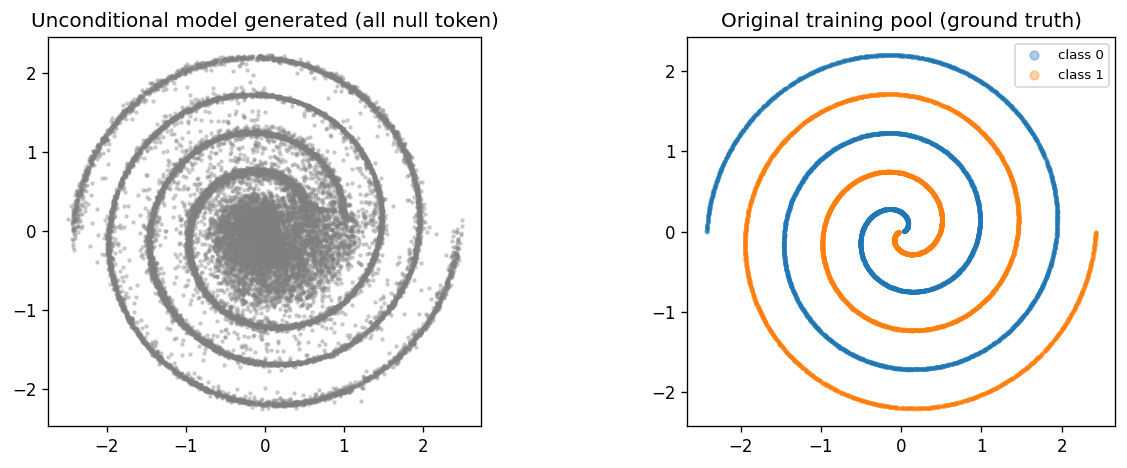

In [ ]:

# Train a model with NO Labels — unconditional flow matching as a baseline.
# All labels are masked to the null token, so the model never sees a real class.
# time_dim=32 and cond_dim=32 must stay non-zero: nn.Embedding(..., 0) on CUDA
# triggers an illegal memory access when the gather kernel reads zero-width rows.
# Functionally this is still unconditional — the label embedding just learns a
# single constant "null" vector that carries no class information.
label_mask_dev_zero = torch.zeros_like(label_mask_dev, dtype=torch.bool)  # all False → all labels masked
noncfg_model = CondMLP(num_in=2, hidden=32, n_classes=N_CLASSES, time_dim=32, cond_dim=32,
                       n_residual=7, x_prediction=False)
noncfg_model_step = make_semi_train_step(p_uncond=0.0, null_idx=noncfg_model.null_idx,
                                         label_mask_vec=label_mask_dev_zero)

noncfg_losses = load_or_train(
    noncfg_model, name="noncfg_spirals_fm", train_step=noncfg_model_step,
    data=pool_x, niter=30000, lr=1e-3,
    ckpt_dir="checkpoints", batch_size=1024,
    load=True, save=True,
)

with sns.axes_style("darkgrid"):
    fig, ax = plt.subplots(figsize=(5, 3), dpi=140)
    ax.semilogy(noncfg_losses, lw=0.7, color='tab:orange')
    ax.set_title('Unconditional FM — training loss (spirals, x-pred)')
    plt.show()

# w=-1 collapses to pure unconditional (null token only). Labels don't distinguish
# classes here so we just plot all generated points in a single colour.
N_GEN_NONCFG_VIS  = 20000
labels_noncfg_vis = torch.zeros(N_GEN_NONCFG_VIS, dtype=torch.long)
gen_noncfg_x      = sample_cfg(noncfg_model, labels_noncfg_vis, w=-1.0, n_steps=50)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=120)
axes[0].scatter(gen_noncfg_x[:, 0], gen_noncfg_x[:, 1], s=3, alpha=0.3, color='tab:gray')
axes[0].set_title('Unconditional model generated (all null token)')
axes[0].set_aspect('equal')
for k in range(N_CLASSES):
    m = pool_y.numpy() == k
    axes[1].scatter(pool_x[m, 0], pool_x[m, 1], s=3, alpha=0.35,
                    color=palette(k), label=f'class {k}')
axes[1].set_title('Original training pool (ground truth)')
axes[1].set_aspect('equal')
axes[1].legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.show()


Loaded standard_fm_spiral from checkpoints/standard_fm_spiral.pt


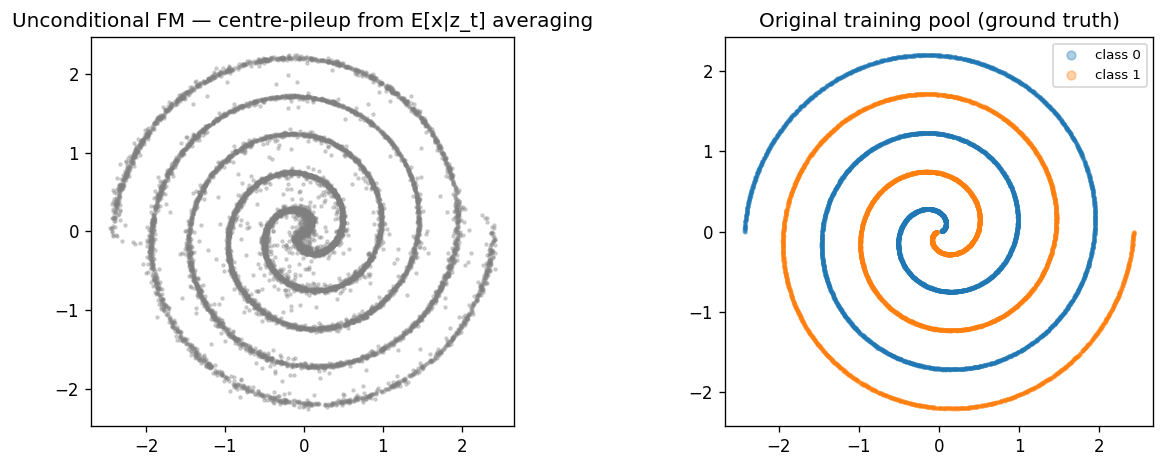

In [ ]:

# Standard unconditional flow matching : it works
def train_step_fm(x, net, optimizer):
    t = sample_t(len(x), eps=0.05 if net.x_prediction else 0).to(x.device)
    e = torch.randn_like(x)
    z = (1 - t) * x + t * e
    v_pred   = net(z, t)
    if net.x_prediction:
        v_target = (z - x) / t
    else:
        v_target = e - x
    loss = F.mse_loss(v_pred, v_target)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    return loss

from common import TinyMLP, generate_samples_euler

model_fm = TinyMLP(2, 64, time_dim=0, x_prediction=False, n_residual=4)
fm_losses = load_or_train(
    model_fm, name="standard_fm_spiral", train_step=train_step_fm,
    data=pool_x, niter=30000, lr=1e-3,
    ckpt_dir="checkpoints", batch_size=1024,
    load=True, save=True,
)

# Use many steps — the spiral flow field is highly curved.
# Even so, centre-pileup will persist due to the multi-modality issue above.
gen_fm_x = generate_samples_euler(model_fm, n_samples=len(pool_x), n_steps=200)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=120)
axes[0].scatter(gen_fm_x[:, 0], gen_fm_x[:, 1], s=3, alpha=0.3, color='tab:gray')
axes[0].set_title('Unconditional FM — centre-pileup from E[x|z_t] averaging')
axes[0].set_aspect('equal')
for k in range(N_CLASSES):
    m = pool_y.numpy() == k
    axes[1].scatter(pool_x[m, 0], pool_x[m, 1], s=3, alpha=0.35,
                    color=palette(k), label=f'class {k}')
axes[1].set_title('Original training pool (ground truth)')
axes[1].set_aspect('equal')
axes[1].legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.show()


[make_semi_train_step] labeled_frac=10.49% < 50%; forcing p_uncond 0 (unlabeled data already trains the null branch).
Loaded cfg_semi_spirals_xpred from checkpoints/cfg_semi_spirals_xpred.pt


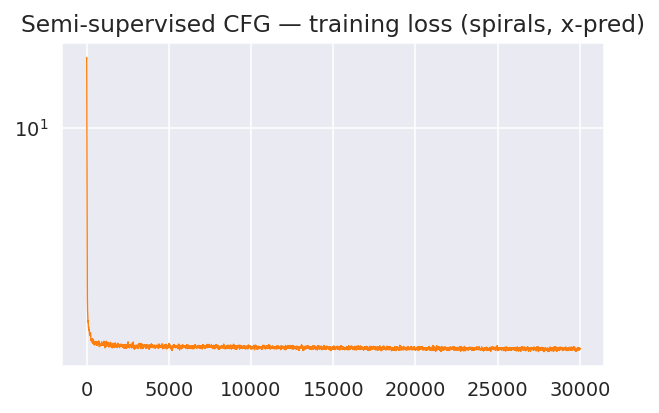

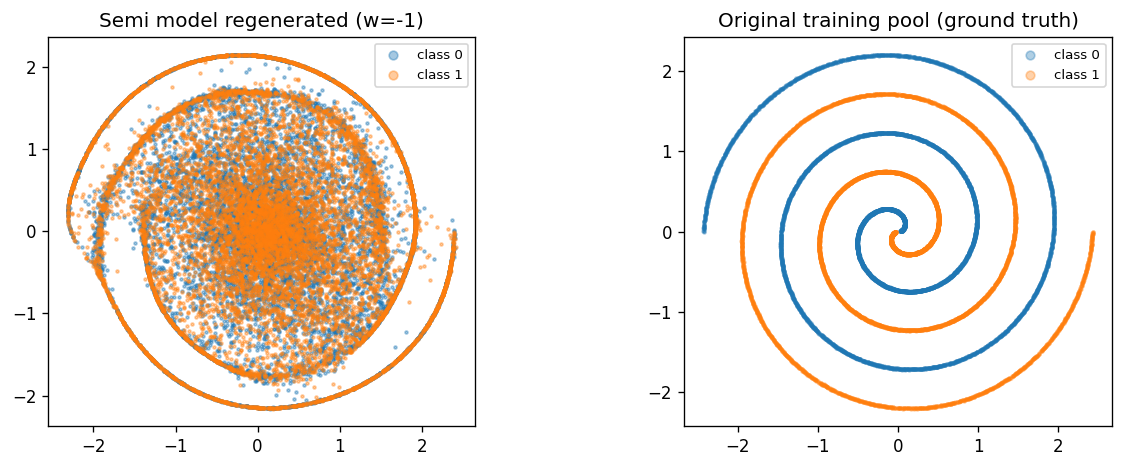

In [8]:
# Train on sparsely labeled data
# pred_type="x": network predicts clean x directly — simpler target, no
# velocity blowup at small t, tends to produce sharper samples on hard geometry.
#
# Note on p_uncond in the semi-supervised regime:
#   effective conditional rate per batch = LABEL_KEEP_FRAC * (1 - p_uncond)
# With LABEL_KEEP_FRAC=0.10 and p_uncond=0.5 → only 5% conditional signal,
# which starves the label embedding. The unlabeled 90% already trains the
# null branch heavily, so set p_uncond low (or 0) here.
semi_model = CondMLP(num_in=2, hidden=64, n_classes=N_CLASSES, time_dim=32, cond_dim=32,
                     n_residual=4, x_prediction=True)
semi_step  = make_semi_train_step(p_uncond=0.5, null_idx=semi_model.null_idx,
                                  label_mask_vec=label_mask_dev)

# load=False while iterating on this cell, otherwise stale checkpoint weights
# (cfg_semi_spirals_xpred.pt) silently shadow your config changes.
semi_losses = load_or_train(
    semi_model, name="cfg_semi_spirals_xpred", train_step=semi_step,
    data=pool_x, niter=30000, lr=1e-3,
    ckpt_dir="checkpoints", batch_size=1024,
    load=True, save=True,
)

with sns.axes_style("darkgrid"):
    fig, ax = plt.subplots(figsize=(5, 3), dpi=140)
    ax.semilogy(semi_losses, lw=0.7, color='tab:orange')
    ax.set_title('Semi-supervised CFG — training loss (spirals, x-pred)')
    plt.show()


# Quick visual sanity check: semi-model regenerated data vs original pool data
N_GEN_SEMI_VIS = 10000
W_SEMI_VIS     = -1

labels_semi_vis = torch.arange(N_CLASSES).repeat_interleave(N_GEN_SEMI_VIS)
gen_semi_x      = sample_cfg(semi_model, labels_semi_vis, w=W_SEMI_VIS, n_steps=150)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=120)

for k in range(N_CLASSES):
    m = labels_semi_vis.numpy() == k
    axes[0].scatter(gen_semi_x[m, 0], gen_semi_x[m, 1], s=3, alpha=0.4,
                    color=palette(k), label=f'class {k}')
axes[0].set_title(f'Semi model regenerated (w={W_SEMI_VIS})')
axes[0].set_aspect('equal')
axes[0].legend(markerscale=3, fontsize=8)

for k in range(N_CLASSES):
    m = pool_y.numpy() == k
    axes[1].scatter(pool_x[m, 0], pool_x[m, 1], s=3, alpha=0.35,
                    color=palette(k), label=f'class {k}')
axes[1].set_title('Original training pool (ground truth)')
axes[1].set_aspect('equal')
axes[1].legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.show()


## Semi-supervised CFG — Mean Flow variant

Conditioning is conceptually unchanged compared to flow matching:

- The network gains a label input $y$ and a null token $\varnothing$, exactly as in `CondMLP`.
- The Mean Flow identity $u = v - (t-r)\,\mathrm{d}u/\mathrm{d}t$ is computed
  with a JVP **only** over $(z, t, r)$; $y$ is held fixed (zero tangent) so the
  label conditioning machinery never enters the JVP.
- Semi-supervised label dropping is identical: replace $y$ with $\varnothing$
  wherever the label is missing (and optionally with random CFG dropout when
  labels are abundant — but with sparse labels we keep `p_uncond=0`).
- CFG at inference: `u_cfg = (1+w) * u_cond − w * u_uncond`, then the same
  $z \leftarrow z - (t-r)\,u_{\text{cfg}}$ update.


In [9]:
# from torch.func import jvp
# from common import SinusoidalTimeEmbedding


# class CondMeanFlowMLP(nn.Module):
#     """Mean Flow backbone with label conditioning (CFG-ready).

#     Mirrors MeanFlowMLP from mean_flow.ipynb but takes an extra label input y.
#     The label embedding is concatenated alongside (z, t, r) — it never enters
#     the JVP because the JVP is taken w.r.t. (z, t, r) only.
#     """
#     def __init__(self, num_in, hidden, n_classes,
#                  time_dim=32, cond_dim=32, n_residual=7):
#         super().__init__()
#         self.n_classes   = n_classes
#         self.null_idx    = n_classes
#         self.time_embed  = SinusoidalTimeEmbedding(time_dim)
#         self.label_embed = nn.Embedding(n_classes + 1, cond_dim)
#         in_features = num_in + 2 * time_dim + cond_dim
#         layers  = [nn.Linear(in_features, hidden), nn.GELU()]
#         layers += [Residual(hidden) for _ in range(n_residual)]
#         layers += [nn.GELU(), nn.Linear(hidden, num_in)]
#         self.mlp = nn.Sequential(*layers)
#         self.x_prediction = False  # kept for API parity with CondMLP

#     def forward(self, z, t, r, y):
#         h = torch.cat([z, self.time_embed(t), self.time_embed(r),
#                        self.label_embed(y)], dim=1)
#         return self.mlp(h)


# def sample_t_r_lognormal(batch_size, device, mu=-0.4, sigma=1.0, flow_ratio=0.5):
#     """Sigmoid(N(mu, sigma)) pairs; collapse a fraction to r=t (plain FM step)."""
#     n = torch.randn(batch_size, 2, device=device) * sigma + mu
#     s = torch.sigmoid(n)
#     t = s.max(dim=1).values[:, None]
#     r = s.min(dim=1).values[:, None]
#     if flow_ratio > 0:
#         mask = torch.rand(batch_size, 1, device=device) < flow_ratio
#         r = torch.where(mask, t, r)
#     return t, r


# def make_semi_train_step_meanflow(p_uncond, null_idx, label_mask_vec=None,
#                                   min_labeled_frac_for_dropout=0.5):
#     """Semi-supervised CFG train step for Mean Flow.

#     Label dropping is identical to the flow-matching version. The mean-flow
#     identity u_tgt = v - (t-r) * du/dt is computed via JVP over (z, t, r),
#     with y held fixed inside the lambda (zero tangent), so no JVP changes
#     are required to support conditioning.
#     """
#     if label_mask_vec is None:
#         label_mask_vec = torch.ones(len(pool_x_dev), dtype=torch.bool, device=pool_x_dev.device)
#     else:
#         label_mask_vec = label_mask_vec.to(pool_x_dev.device).bool()

#     labeled_frac = label_mask_vec.float().mean().item()
#     effective_p_uncond = p_uncond
#     if labeled_frac < min_labeled_frac_for_dropout and p_uncond > 0.0:
#         print(f"[meanflow] labeled_frac={labeled_frac:.2%} < "
#               f"{min_labeled_frac_for_dropout:.0%}; forcing p_uncond=0.")
#         effective_p_uncond = 0.0

#     def train_step(x, net, optimizer):
#         idx = torch.randint(0, len(pool_x_dev), (len(x),), device=x.device)
#         x_b = pool_x_dev[idx]
#         y_b = pool_y_dev[idx].clone()

#         has_label = label_mask_vec[idx]
#         if effective_p_uncond > 0.0:
#             random_drop = torch.rand(len(y_b), device=y_b.device) < effective_p_uncond
#             y_b[~has_label | random_drop] = null_idx
#         else:
#             y_b[~has_label] = null_idx

#         t, r = sample_t_r_lognormal(len(x_b), x_b.device)
#         e    = torch.randn_like(x_b)
#         z    = (1 - t) * x_b + t * e
#         v    = e - x_b

#         dtdt = torch.ones_like(t)
#         drdt = torch.zeros_like(r)
#         # JVP over (z, t, r); y_b is closed over, no tangent → unaffected.
#         u, dudt = jvp(lambda z_, t_, r_: net(z_, t_, r_, y_b),
#                       (z, t, r), (v, dtdt, drdt))
#         u_tgt = v - (t - r) * dudt

#         err  = ((u - u_tgt.detach()) ** 2).sum(dim=1)
#         w_   = (err.detach() + 1e-3) ** 0.75   # adaptive p-norm weighting
#         loss = (err / w_).mean()

#         optimizer.zero_grad(); loss.backward(); optimizer.step()
#         return loss
#     return train_step


# @torch.no_grad()
# def sample_cfg_meanflow(model, labels, w=0.0, n_steps=1):
#     """K-step CFG mean-flow sampler. n_steps=1 = headline 1-NFE generator."""
#     model.eval()
#     dev    = next(model.parameters()).device
#     labels = labels.to(dev)
#     null   = torch.full_like(labels, model.null_idx)
#     n      = labels.shape[0]
#     z      = torch.randn(n, 2, device=dev)
#     t_vals = torch.linspace(1.0, 0.0, n_steps + 1, device=dev)
#     for i in range(n_steps):
#         t = torch.full((n, 1), float(t_vals[i]),     device=dev)
#         r = torch.full((n, 1), float(t_vals[i + 1]), device=dev)
#         u_cond   = model(z, t, r, labels)
#         u_uncond = model(z, t, r, null)
#         u        = (1 + w) * u_cond - w * u_uncond
#         z = z - (t - r) * u
#     return z.cpu()



# mf_model = CondMeanFlowMLP(num_in=2, hidden=64, n_classes=N_CLASSES,
#                            time_dim=32, cond_dim=32, n_residual=4)
# mf_step  = make_semi_train_step_meanflow(p_uncond=0.0,
#                                          null_idx=mf_model.null_idx,
#                                          label_mask_vec=label_mask_dev)
# mf_losses = load_or_train(
#     mf_model, name="cfg_semi_spirals_meanflow", train_step=mf_step,
#     data=pool_x, niter=30000, lr=1e-3,
#     ckpt_dir="checkpoints", batch_size=1024, load=False, save=True,
# )
# gen_mf_x = sample_cfg_meanflow(mf_model,
#                                torch.arange(N_CLASSES).repeat_interleave(5000),
#                                w=0.0, n_steps=1)



# fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=120)

# for k in range(N_CLASSES):
#     m = label_mask_dev.cpu().numpy() == k
#     axes[0].scatter(gen_mf_x[m, 0], gen_mf_x[m, 1], s=3, alpha=0.4,
#                     color=palette(k), label=f'class {k}')
# axes[0].set_title(f'Semi model regenerated (w={W_SEMI_VIS})')
# axes[0].set_aspect('equal')
# axes[0].legend(markerscale=3, fontsize=8)

# for k in range(N_CLASSES):
#     m = pool_y.numpy() == k
#     axes[1].scatter(pool_x[m, 0], pool_x[m, 1], s=3, alpha=0.35,
#                     color=palette(k), label=f'class {k}')
# axes[1].set_title('Original training pool (ground truth)')
# axes[1].set_aspect('equal')
# axes[1].legend(markerscale=3, fontsize=8)

# plt.tight_layout()
# plt.show()


## Generate synthetic $(x, y)$ pairs and evaluate

(C) CFG-regenerated (w=0.0) → 82.2%


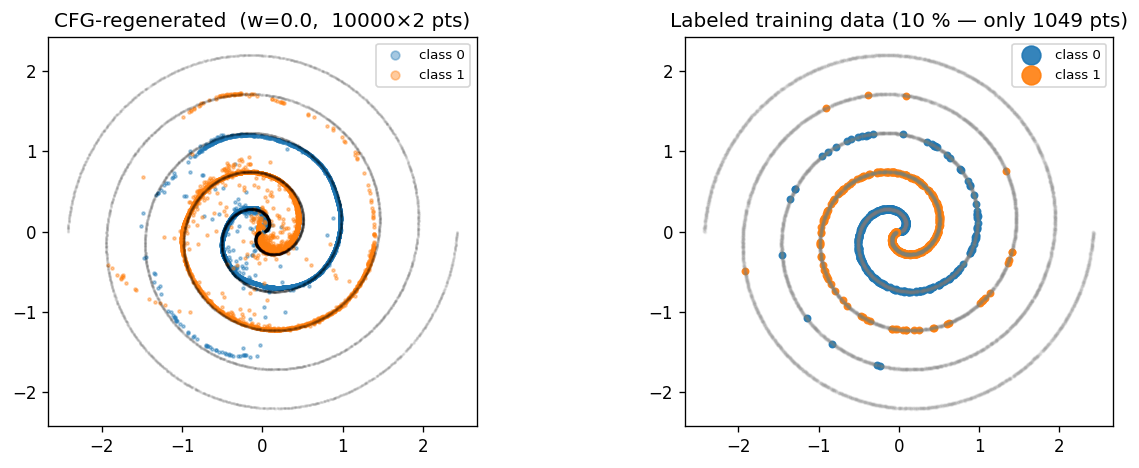


────────────────────────────────────────────────────────
Method                                  Accuracy
────────────────────────────────────────────────────────
(A) Full labels (100%)                   100.0%  ██████████████████████████████
(B) Direct — 10% labels (1049 pts)        82.6%  ████████████████████████
(C) CFG-regen (semi-sup)                  82.2%  ████████████████████████
────────────────────────────────────────────────────────


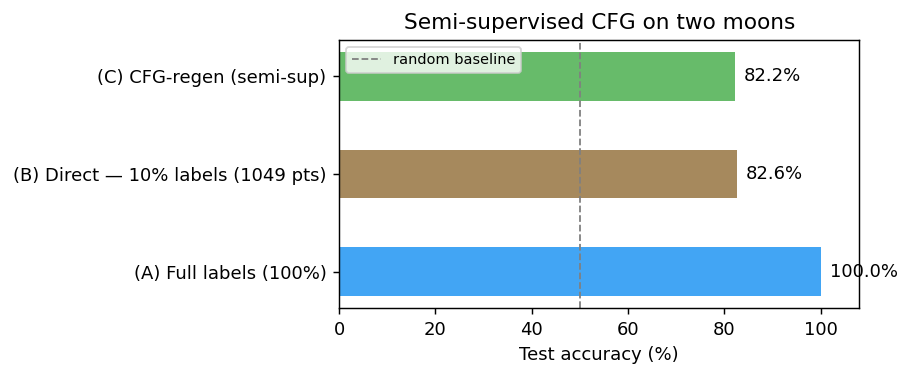

In [10]:
N_GEN_PER_CLASS = 10000
W_GEN        = 0.0    # mild guidance sharpens the boundary
SNAP_TO_DATA = 0   # replace each generated point with its nearest pool neighbour

labels_gen = torch.arange(N_CLASSES).repeat_interleave(N_GEN_PER_CLASS)
gen_x_raw  = sample_cfg(semi_model, labels_gen, w=W_GEN, n_steps=50)

def snap_to_pool(gen_x, pool_x, chunk=500):
    """Replace each generated point with its nearest neighbour in pool_x.

    Processes in chunks to keep peak memory bounded (~chunk × |pool| floats).
    """
    snapped = torch.empty_like(gen_x)
    for start in range(0, len(gen_x), chunk):
        end   = min(start + chunk, len(gen_x))
        dists = torch.cdist(gen_x[start:end], pool_x)   # (chunk, |pool|)
        idx   = dists.argmin(dim=1)
        snapped[start:end] = pool_x[idx]
    return snapped

gen_x = snap_to_pool(gen_x_raw, pool_x) if SNAP_TO_DATA else gen_x_raw
gen_y = labels_gen.clone()

clf_regen = train_clf(gen_x, gen_y)
acc_regen = test_acc(clf_regen, test_x, test_y)
snap_tag  = " + snap" if SNAP_TO_DATA else ""
print(f"(C) CFG-regenerated (w={W_GEN}{snap_tag}) → {acc_regen*100:.1f}%")

# ── Visualise generated data ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=120)
for k in range(N_CLASSES):
    m = labels_gen.numpy() == k
    axes[0].scatter(gen_x[m, 0], gen_x[m, 1], s=3, alpha=0.4,
                    color=palette(k), label=f'class {k}')
axes[0].scatter(pool_x[:, 0], pool_x[:, 1], s=1, color='black', alpha=0.04)
axes[0].set_title(f'CFG-regenerated  (w={W_GEN}{snap_tag},  {N_GEN_PER_CLASS}×{N_CLASSES} pts)')
axes[0].set_aspect('equal')
axes[0].legend(markerscale=3, fontsize=8)

for k in range(N_CLASSES):
    m = labeled_y.numpy() == k
    axes[1].scatter(labeled_x[m, 0], labeled_x[m, 1],
                    s=14, alpha=0.9, color=palette(k), label=f'class {k}')
axes[1].scatter(pool_x[~label_mask, 0], pool_x[~label_mask, 1],
                s=2, alpha=0.08, color='gray')
axes[1].set_title(f'Labeled training data ({LABEL_KEEP_FRAC*100:.0f} % — only {n_labeled} pts)')
axes[1].set_aspect('equal')
axes[1].legend(markerscale=3, fontsize=8)
plt.tight_layout()
plt.show()

# ── Accuracy comparison ───────────────────────────────────────────────────────
results = {
    "(A) Full labels (100%)": acc_full,
    f"(B) Direct — {LABEL_KEEP_FRAC*100:.0f}% labels ({n_labeled} pts)": acc_direct,
    f"(C) CFG-regen{snap_tag} (semi-sup)": acc_regen,
}

print("\n" + "─" * 56)
print(f"{'Method':<38s}  {'Accuracy':>8s}")
print("─" * 56)
for name, acc in results.items():
    bar = "█" * int(acc * 30)
    print(f"{name:<38s}  {acc*100:6.1f}%  {bar}")
print("─" * 56)

fig, ax = plt.subplots(figsize=(7, 3), dpi=130)
names  = list(results.keys())
vals   = [v * 100 for v in results.values()]
colors = ['#2196F3', "#977440", '#4CAF50']
bars   = ax.barh(names, vals, color=colors, alpha=0.85, height=0.5)
ax.bar_label(bars, fmt='%.1f%%', padding=5)
ax.set_xlim(0, 108)
ax.axvline(50, color='gray', lw=1, ls='--', label='random baseline')
ax.set_xlabel('Test accuracy (%)')
ax.set_title('Semi-supervised CFG on two moons')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
